# `gen_ell_grid` fidelity check

Tune `nside` / `theta_pix`, build the 2D `ell_grid` from `cmb_lensing.util.gen_ell_grid`, interpolate the true CAMB Cls (TT, TE, EE) onto that grid using the **same interpolators the pipeline uses** (`covar_matrix_from_cls` log-log interpolation for TT/EE, the `rho = Cl_TE / sqrt(Cl_TT * Cl_EE)` linear-interpolation path for the sign-changing TE), then overlay the grid-interpolated Cls against the true CAMB spectra.

Grid points with ell above the CAMB support (`lmax - 1`) are log-log **extrapolated** by the pipeline — they show up here as the tail beyond the dashed vertical line.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)

from cmb_lensing.util import gen_ell_grid
from cmb_lensing.simulate import (_run_camb, dl2cl, covar_matrix_from_cls,
                                  te_rho_from_cls, te_covar_from_rho)

## Tunable parameters

`nside` and `theta_pix` are the knobs. The cosmological parameters below are the `load_sim` defaults (ground truth) so the spectra match what the sampler's data maps are built from.

In [15]:
#grid knobs - change these and re-run the notebook from here down
nside = 512       #map is nside x nside pixels
theta_pix = 3  #arcmin per pixel

#CAMB setup, mirroring load_sim's defaults
lmax = 4000
lmax_prime = min(lmax, 4000)
camb_params = dict(H0 = None, ombh2 = 0.0224567, omch2 = 0.118489,
                   cosmomc_theta = 0.0104098, r = 0.0, mnu = 0.06, tau = 0.05,
                   As = float(jnp.exp(3.043) * 1e-10), nt = 0, ns = 0.968602,
                   k_pivot = 0.05, Alens = 1)

## True CAMB Cls

Run CAMB once and convert the returned Dls to Cls with `dl2cl`, exactly as `load_sim`'s `_extract_all_cls` does for the unlensed scalar spectra. The result lives on integer ells `2 .. lmax - 1`.

In [16]:
power_spectra, lens_potential = _run_camb(**camb_params, lmax_prime = lmax_prime)
unlensed_scalar = jnp.asarray(power_spectra["unlensed_scalar"], dtype = jnp.float64)

#CAMB column order is TT, EE, BB, TE (simulate._CAMB_COLS)
camb_cols = {"TT": 0, "EE": 1, "TE": 3}
ells = jnp.arange(2, lmax).astype(jnp.float64)
cl_true = {stokes: dl2cl(unlensed_scalar[:, col], lmax, lmax_prime)
           for stokes, col in camb_cols.items()}

print(f"true Cls on integer ells {int(ells[0])} .. {int(ells[-1])} "
      f"({ells.shape[0]} multipoles)")

true Cls on integer ells 2 .. 3999 (3998 multipoles)


## `ell_grid` and the pipeline's interpolation onto it

TT/EE go through `covar_matrix_from_cls`, the pipeline's log-log interpolator (with `rescale = False` here so the values stay in Cl units instead of being divided by `pix_width**2`, and `origin_value = 0` for the ell = 0 monopole). TE goes through the pipeline's `rho` path: linear interpolation of the correlation ratio, scaled by the *interpolated* TT/EE.

In [17]:
ell_grid, pix_width = gen_ell_grid(nside, theta_pix)

print(f"ell_grid shape = {ell_grid.shape}, pix_width = {pix_width:.6f} rad")
print(f"fundamental mode delta_ell = {2 * jnp.pi / (nside * pix_width):.2f}")
print(f"max grid ell = {float(ell_grid.max()):.1f} "
      f"(CAMB support ends at ell = {lmax - 1})")

cl_interp = {}
for stokes in ("TT", "EE"):
    cl_interp[stokes] = covar_matrix_from_cls(nside, pix_width, ell_grid, ells,
                                              cl_true[stokes], origin_value = 0.0,
                                              rescale = False)

#TE crosses zero so it cannot go through the log-log interpolator - reconstruct it
#from the linearly-interpolated correlation ratio, exactly as load_sim does
rho = te_rho_from_cls(cl_true["TE"], cl_true["TT"], cl_true["EE"])
cl_interp["TE"] = te_covar_from_rho(rho, ells, ell_grid,
                                    cl_interp["TT"], cl_interp["EE"])

#flatten and sort the grid by ell for plotting; drop the ell = 0 monopole
ell_flat = np.asarray(ell_grid).flatten()
order = np.argsort(ell_flat)
keep = ell_flat[order] > 0
ell_sorted = ell_flat[order][keep]
cl_interp_sorted = {stokes: np.asarray(cl_interp[stokes]).flatten()[order][keep]
                    for stokes in cl_interp}

ell_grid shape = (512, 257), pix_width = 0.000873 rad
fundamental mode delta_ell = 14.06
max grid ell = 5091.2 (CAMB support ends at ell = 3999)


## Overlay: grid-interpolated Cls vs true CAMB Cls

Black line = true CAMB spectrum on integer ells. Orange dots = the value the pipeline assigns to each `ell_grid` mode. TE changes sign, so its panel uses a symlog y-axis. The dashed line marks the end of CAMB support - dots to its right are the pipeline's log-log extrapolation.

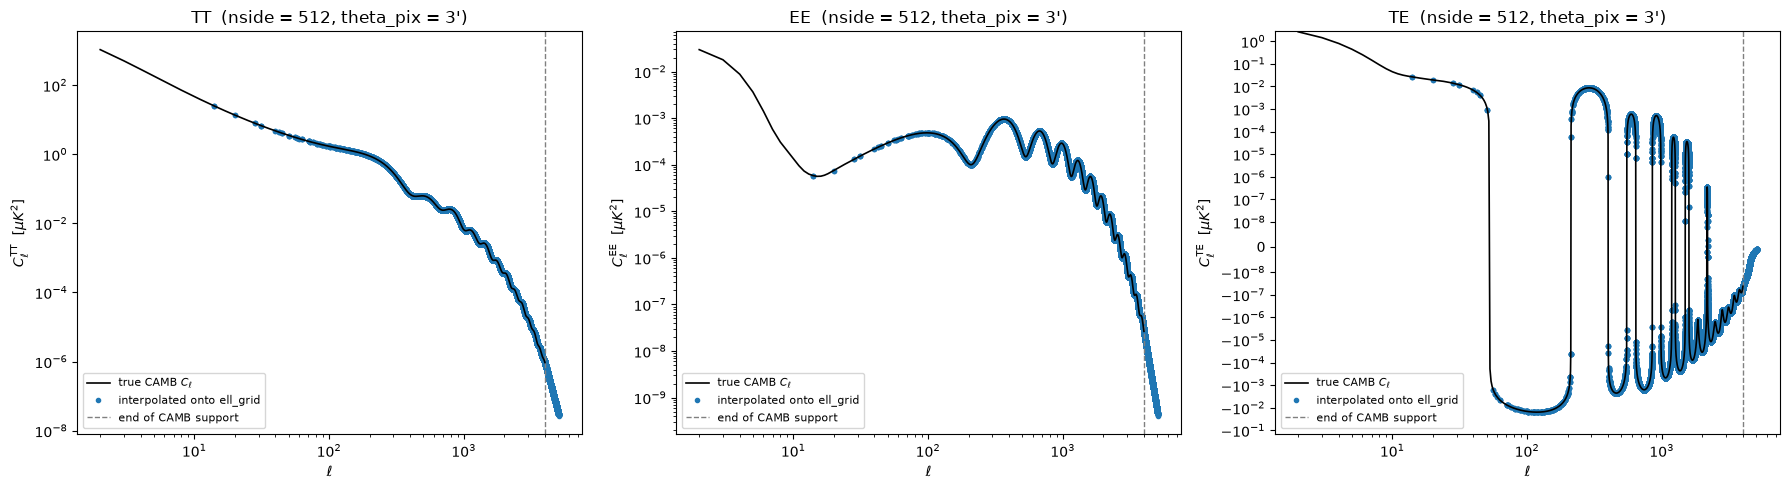

In [18]:
fig, axes = plt.subplots(1, 3, figsize = (18, 5))
for ax, stokes in zip(axes, ("TT", "EE", "TE")):
    ax.plot(np.asarray(ells), np.asarray(cl_true[stokes]), color = "k", lw = 1.2,
            label = "true CAMB $C_\\ell$", zorder = 3)
    ax.plot(ell_sorted, cl_interp_sorted[stokes], ".", 
            color = "tab:blue", label = "interpolated onto ell_grid")
    ax.axvline(lmax - 1, color = "gray", ls = "--", lw = 1,
               label = "end of CAMB support")
    ax.set_xscale("log")
    if stokes == "TE":
        ax.set_yscale("symlog", linthresh = 1e-8)
    else:
        ax.set_yscale("log")
    ax.set_xlabel(r"$\ell$")
    ax.set_ylabel(rf"$C_\ell^{{\rm {stokes}}}$  [$\mu K^2$]")
    ax.set_title(f"{stokes}  (nside = {nside}, theta_pix = {theta_pix}')")
    ax.legend(fontsize = 8)
plt.tight_layout()
plt.show()

## Fractional residuals at the grid ells

How far off is the interpolated value at each grid mode from the truth? The truth at a non-integer grid ell is taken as linear interpolation of the integer-ell CAMB Cl (a fair reference: any smooth interpolant of the truth agrees with this to well below the log-log-vs-linear difference being measured). Grid modes outside the CAMB support are excluded - there is no truth to compare against out there.

TT/EE show `(interp - truth) / truth`. TE crosses zero, so its residual is normalized by `sqrt(Cl_TT * Cl_EE)` instead (i.e. the error expressed as a shift in the correlation ratio rho).

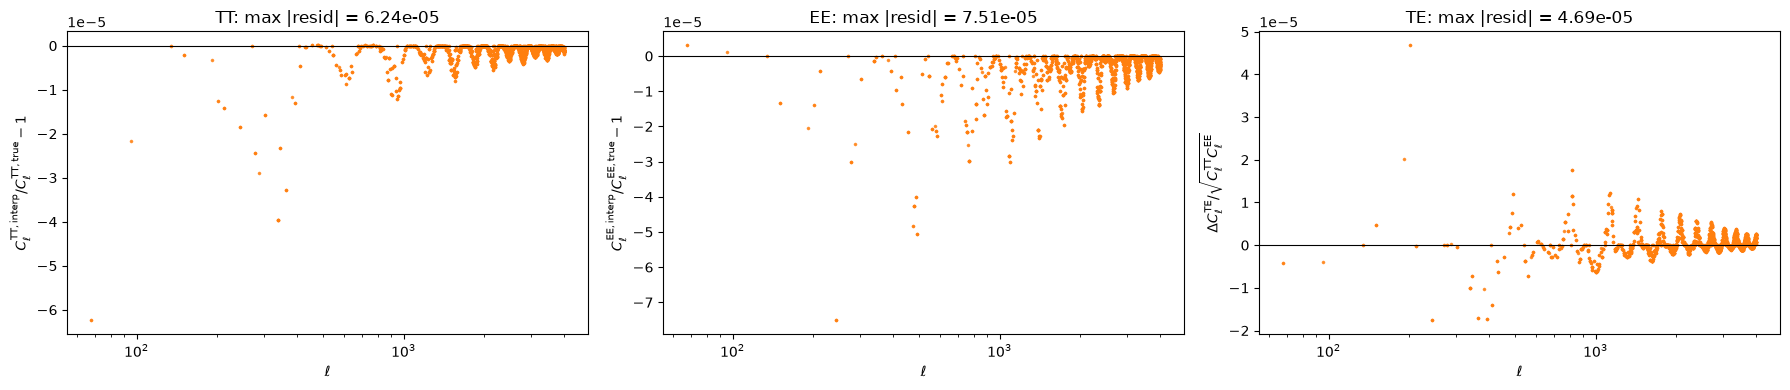

In [6]:
inside = (ell_sorted >= 2) & (ell_sorted <= lmax - 1)
ell_in = ell_sorted[inside]

truth_at_grid = {stokes: np.interp(ell_in, np.asarray(ells),
                                   np.asarray(cl_true[stokes]))
                 for stokes in cl_true}

fig, axes = plt.subplots(1, 3, figsize = (18, 4))
for ax, stokes in zip(axes, ("TT", "EE", "TE")):
    interp_in = cl_interp_sorted[stokes][inside]
    if stokes == "TE":
        norm = np.sqrt(truth_at_grid["TT"] * truth_at_grid["EE"])
        resid = (interp_in - truth_at_grid[stokes]) / norm
        ylabel = r"$\Delta C_\ell^{\rm TE} / \sqrt{C_\ell^{\rm TT} C_\ell^{\rm EE}}$"
    else:
        resid = interp_in / truth_at_grid[stokes] - 1
        ylabel = rf"$C_\ell^{{\rm {stokes}, interp}} / C_\ell^{{\rm {stokes}, true}} - 1$"
    ax.plot(ell_in, resid, ".", ms = 3, alpha = 0.5, color = "tab:orange")
    ax.axhline(0, color = "k", lw = 0.8)
    ax.set_xscale("log")
    ax.set_xlabel(r"$\ell$")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{stokes}: max |resid| = {np.max(np.abs(resid)):.2e}")
plt.tight_layout()
plt.show()